# Pulmonary Nodule Detection and Classification using YOLO11n

## Project Overview

This project trains and evaluates a **YOLO11n (Nano) object-detection model** on the prepared LIDC-IDRI CT Lung Detection dataset.

The model detects pulmonary nodules and classifies them into three categories:

- **Benign**
- **Equivocal**
- **Malignant**

The notebook covers dataset verification and analysis, model configuration, optional training, final test-set evaluation, qualitative prediction examples, and single-image inference.

> **Research prototype:** The model and web application are intended for research, educational, and demonstration purposes only. They are not medical diagnostic tools.


## 1. Install Libraries

In [1]:
# ============================================================
# 1. INSTALL LIBRARIES
# ============================================================

!pip install -q ultralytics==8.4.137 gradio pyyaml opencv-python matplotlib pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.3 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import re
import random
from pathlib import Path
from collections import Counter

import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from IPython.display import display

from ultralytics import YOLO

print("Libraries imported successfully.")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Libraries imported successfully.


## 3. Mount Google Drive

In [3]:
# ============================================================
# 3. MOUNT GOOGLE DRIVE (COLAB)
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted successfully.")
except ImportError:
    print("Google Colab is not available. Use local paths in Section 4.")


Mounted at /content/drive
Google Drive mounted successfully.


## 4. Dataset and Project Configuration

The prepared dataset is stored in Google Drive. The notebook does not download the dataset automatically, which avoids exposing credentials and avoids repeatedly downloading a large dataset.

For a different environment, change `DATASET_PATH` to the local location of the prepared dataset.

In [4]:
# ============================================================
# 4. DATASET AND PROJECT CONFIGURATION
# ============================================================

# The paths can be overridden with environment variables.
# This keeps the notebook free of personal/local machine paths
# when it is shared on GitHub.

IS_COLAB = os.path.exists("/content/drive/MyDrive")

if IS_COLAB:
    DEFAULT_DATASET_PATH = "/content/drive/MyDrive/LIDC-IDRI-CT-Lung-Detection-2-1"
    DEFAULT_PROJECT_ROOT = "/content/drive/MyDrive/Pulmonary_Nodule_Detection"
else:
    DEFAULT_DATASET_PATH = "./data/LIDC-IDRI-CT-Lung-Detection-2-1"
    DEFAULT_PROJECT_ROOT = "./runs"

DATASET_PATH = os.getenv("DATASET_PATH", DEFAULT_DATASET_PATH)
PROJECT_ROOT = os.getenv("PROJECT_ROOT", DEFAULT_PROJECT_ROOT)

MODEL_PATH = os.getenv(
    "MODEL_PATH",
    os.path.join(PROJECT_ROOT, "yolo11n_final", "weights", "best.pt")
)

TEST_RESULTS_DIR = os.path.join(PROJECT_ROOT, "yolo11n_final_test")
TRAIN_RUN_DIR = os.path.join(PROJECT_ROOT, "yolo11n_final")

TRAIN_IMAGES = os.path.join(DATASET_PATH, "train", "images")
TRAIN_LABELS = os.path.join(DATASET_PATH, "train", "labels")
VALID_IMAGES = os.path.join(DATASET_PATH, "valid", "images")
VALID_LABELS = os.path.join(DATASET_PATH, "valid", "labels")
TEST_IMAGES = os.path.join(DATASET_PATH, "test", "images")
TEST_LABELS = os.path.join(DATASET_PATH, "test", "labels")
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

print("Dataset:", DATASET_PATH)
print("Model:", MODEL_PATH)
print("Test results:", TEST_RESULTS_DIR)


Dataset: /content/drive/MyDrive/LIDC-IDRI-CT-Lung-Detection-2-1
Model: /content/drive/MyDrive/Pulmonary_Nodule_Detection/yolo11n_final/weights/best.pt
Test results: /content/drive/MyDrive/Pulmonary_Nodule_Detection/yolo11n_final_test


## 5. Dataset Verification

In [5]:
# ============================================================
# 5. DATASET VERIFICATION
# ============================================================

required_paths = [
    DATASET_PATH,
    TRAIN_IMAGES,
    TRAIN_LABELS,
    VALID_IMAGES,
    VALID_LABELS,
    TEST_IMAGES,
    TEST_LABELS,
    DATA_YAML
]

for path in required_paths:
    assert os.path.exists(path), f"Missing path: {path}"

def image_count(folder):
    return sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    )

def label_count(folder):
    return sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith(".txt")
    )

print("=" * 60)
print("DATASET STRUCTURE VERIFIED")
print("=" * 60)

print(f"Train      : {image_count(TRAIN_IMAGES):,} images | {label_count(TRAIN_LABELS):,} labels")
print(f"Validation : {image_count(VALID_IMAGES):,} images | {label_count(VALID_LABELS):,} labels")
print(f"Test       : {image_count(TEST_IMAGES):,} images | {label_count(TEST_LABELS):,} labels")

DATASET STRUCTURE VERIFIED
Train      : 16,354 images | 16,354 labels
Validation : 2,672 images | 2,672 labels
Test       : 1,337 images | 1,337 labels


## 6. Dataset Information

In [6]:
# ============================================================
# 6. DATASET INFORMATION
# ============================================================

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

CLASS_NAMES = data["names"]

print("Dataset configuration:")
print("-" * 60)
print(f"Number of classes: {data['nc']}")
print(f"Classes: {CLASS_NAMES}")
print(f"Train path: {data['train']}")
print(f"Validation path: {data['val']}")
print(f"Test path: {data['test']}")

Dataset configuration:
------------------------------------------------------------
Number of classes: 3
Classes: ['benign', 'equivocal', 'malignant']
Train path: ../train/images
Validation path: ../valid/images
Test path: ../test/images


### 6.1 Class Distribution

In [7]:
# ============================================================
# 6.1 CLASS DISTRIBUTION
# ============================================================

def count_classes(label_dir):
    counts = Counter()

    for filename in os.listdir(label_dir):
        if not filename.endswith(".txt"):
            continue

        with open(os.path.join(label_dir, filename), "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) >= 5:
                    class_id = int(parts[0])
                    counts[class_id] += 1

    return counts

train_counts = count_classes(TRAIN_LABELS)
valid_counts = count_classes(VALID_LABELS)
test_counts = count_classes(TEST_LABELS)

for split_name, counts in [
    ("TRAIN", train_counts),
    ("VALIDATION", valid_counts),
    ("TEST", test_counts)
]:
    total = sum(counts.values())

    print("\n" + "=" * 60)
    print(split_name)
    print("=" * 60)

    for class_id, class_name in enumerate(CLASS_NAMES):
        count = counts[class_id]
        percentage = 100 * count / total if total else 0

        print(
            f"{class_name:12s}: "
            f"{count:5d} objects "
            f"({percentage:.2f}%)"
        )

    print(f"Total objects: {total}")


TRAIN
benign      :  7119 objects (40.71%)
equivocal   :  6307 objects (36.07%)
malignant   :  4061 objects (23.22%)
Total objects: 17487

VALIDATION
benign      :  1231 objects (42.64%)
equivocal   :  1018 objects (35.26%)
malignant   :   638 objects (22.10%)
Total objects: 2887

TEST
benign      :   608 objects (42.25%)
equivocal   :   501 objects (34.82%)
malignant   :   330 objects (22.93%)
Total objects: 1439


### 6.2 Class Distribution Visualization

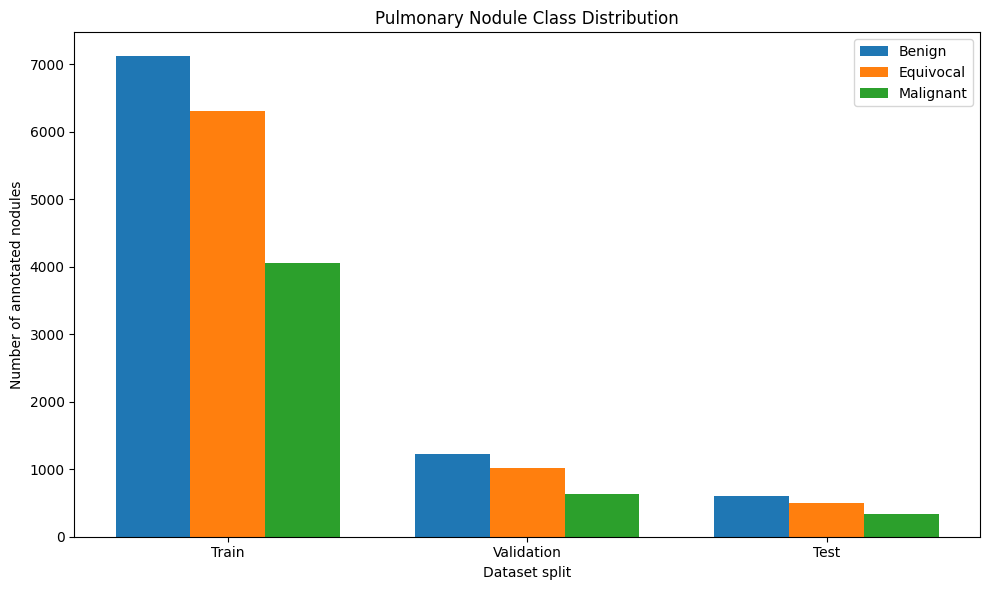

In [8]:
# ============================================================
# 6.2 CLASS DISTRIBUTION VISUALIZATION
# ============================================================

splits = ["Train", "Validation", "Test"]

values = np.array([
    [train_counts[i] for i in range(len(CLASS_NAMES))],
    [valid_counts[i] for i in range(len(CLASS_NAMES))],
    [test_counts[i] for i in range(len(CLASS_NAMES))]
])

x = np.arange(len(splits))
width = 0.25

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(CLASS_NAMES):
    plt.bar(
        x + (i - 1) * width,
        values[:, i],
        width,
        label=class_name.capitalize()
    )

plt.xticks(x, splits)
plt.xlabel("Dataset split")
plt.ylabel("Number of annotated nodules")
plt.title("Pulmonary Nodule Class Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Patient-Level Split Audit

In [9]:
# ============================================================
# 6.3 PATIENT-LEVEL SPLIT AUDIT
# ============================================================

# The prepared dataset is split at the image level.
# We audit patient IDs so that the overlap is documented
# rather than silently ignored.

def get_patient_ids(folder):
    patient_ids = set()

    for filename in os.listdir(folder):
        match = re.match(r"(LIDC-IDRI-\d+)", filename)

        if match:
            patient_ids.add(match.group(1))

    return patient_ids

patient_ids = {
    "train": get_patient_ids(TRAIN_IMAGES),
    "valid": get_patient_ids(VALID_IMAGES),
    "test": get_patient_ids(TEST_IMAGES)
}

for split, ids in patient_ids.items():
    print(f"{split:10s}: {len(ids):4d} unique patients")

train_valid = patient_ids["train"] & patient_ids["valid"]
train_test = patient_ids["train"] & patient_ids["test"]
valid_test = patient_ids["valid"] & patient_ids["test"]

print("\n" + "=" * 60)
print("PATIENT OVERLAP AUDIT")
print("=" * 60)

print("Train ∩ Validation:", len(train_valid))
print("Train ∩ Test:      ", len(train_test))
print("Validation ∩ Test: ", len(valid_test))

if train_valid or train_test or valid_test:
    print(
        "\nNOTE: The prepared dataset contains patients appearing "
        "in more than one split. This is documented as a limitation "
        "of the prepared image-level split."
    )
else:
    print("\nNo patient overlap detected.")

train     :  867 unique patients
valid     :  708 unique patients
test      :  556 unique patients

PATIENT OVERLAP AUDIT
Train ∩ Validation: 700
Train ∩ Test:       552
Validation ∩ Test:  479

NOTE: The prepared dataset contains patients appearing in more than one split. This is documented as a limitation of the prepared image-level split.


### 6.4 Sample CT Images and Ground-Truth Annotations

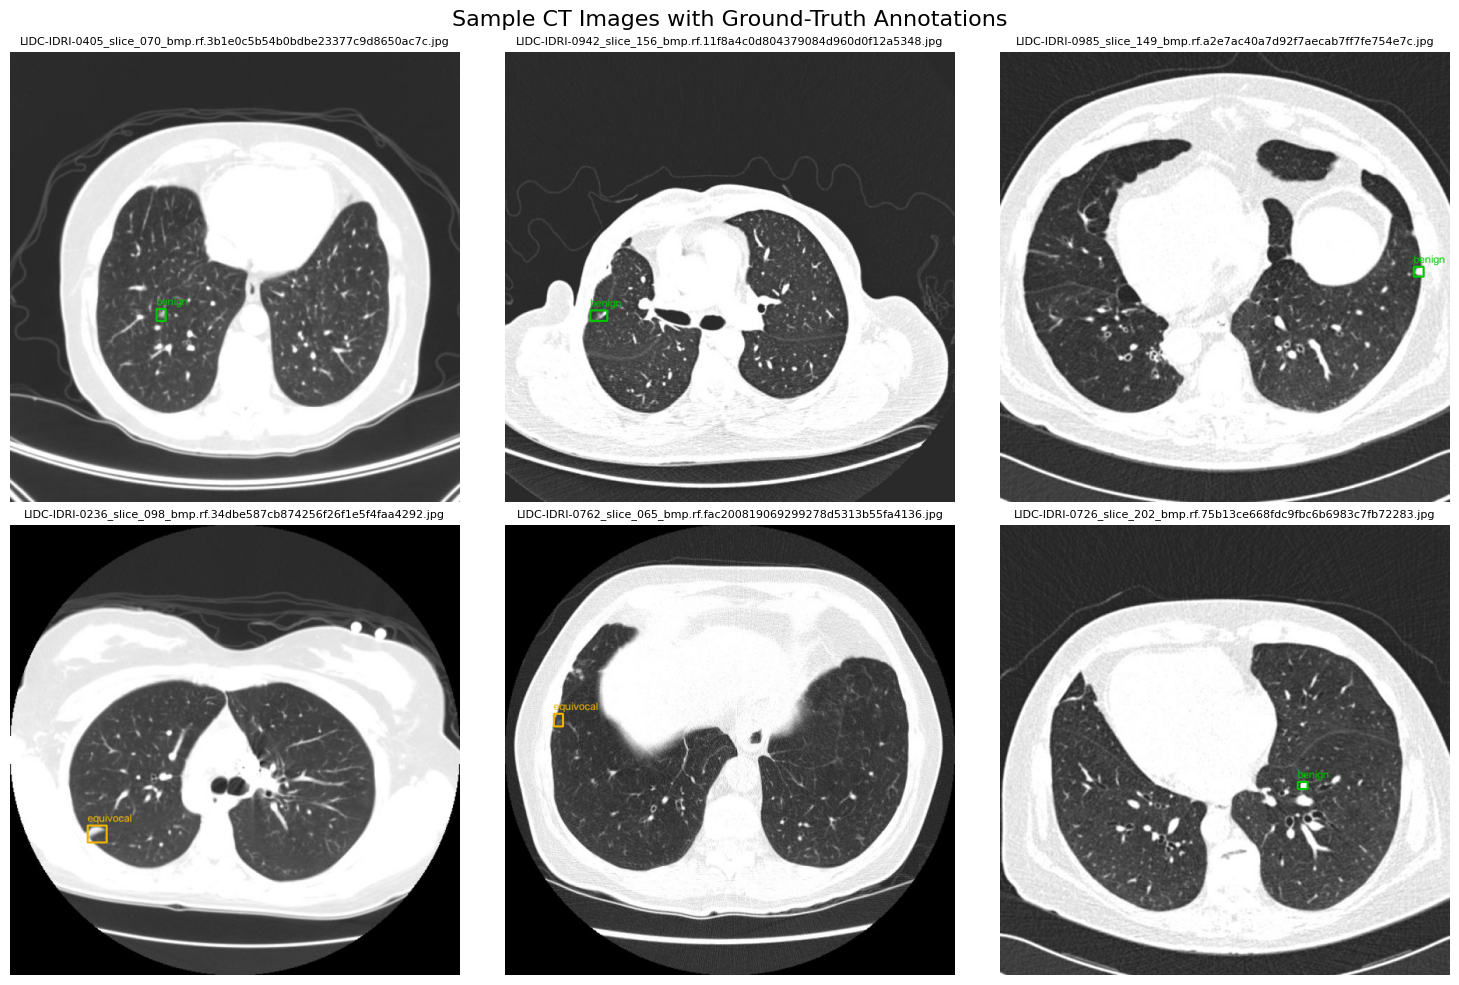

In [10]:
# ============================================================
# 6.4 SAMPLE CT IMAGES AND GROUND-TRUTH ANNOTATIONS
# ============================================================

CLASS_COLORS = {
    0: (0, 200, 0),
    1: (240, 180, 0),
    2: (220, 40, 40)
}

def show_samples(image_dir, label_dir, n=6, seed=42):

    rng = random.Random(seed)

    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    selected = rng.sample(image_files, min(n, len(image_files)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for ax, image_name in zip(axes, selected):

        image_path = os.path.join(image_dir, image_name)
        label_path = os.path.join(
            label_dir,
            Path(image_name).stem + ".txt"
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        if os.path.exists(label_path):

            with open(label_path, "r") as f:

                for line in f:

                    parts = line.strip().split()

                    if len(parts) < 5:
                        continue

                    cls, xc, yc, bw, bh = map(float, parts[:5])
                    cls = int(cls)

                    x1 = int((xc - bw / 2) * w)
                    y1 = int((yc - bh / 2) * h)
                    x2 = int((xc + bw / 2) * w)
                    y2 = int((yc + bh / 2) * h)

                    color = CLASS_COLORS.get(cls, (255, 255, 255))

                    cv2.rectangle(
                        image,
                        (x1, y1),
                        (x2, y2),
                        color,
                        2
                    )

                    cv2.putText(
                        image,
                        CLASS_NAMES[cls],
                        (x1, max(15, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        color,
                        1,
                        cv2.LINE_AA
                    )

        ax.imshow(image)
        ax.set_title(image_name, fontsize=8)
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.suptitle(
        "Sample CT Images with Ground-Truth Annotations",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_IMAGES, TRAIN_LABELS)

## 7. YOLO11n Model Configuration

The project uses **YOLO11n (Nano)**, a lightweight YOLO11 model for object detection.

The previously trained `best.pt` checkpoint is used for evaluation and inference. The training cell is included to document the training configuration and allow reproduction when `RUN_TRAINING` is explicitly changed to `True`.

Training is disabled by default so that opening or running the notebook does not accidentally start a new 50-epoch training run.


In [11]:
# ============================================================
# 7. MODEL CONFIGURATION
# ============================================================

MODEL_NAME = "yolo11n.pt"

EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 16
WORKERS = 2

RUN_TRAINING = False

print("Model:", MODEL_NAME)
print("Epochs:", EPOCHS)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Run training:", RUN_TRAINING)

Model: yolo11n.pt
Epochs: 50
Image size: 640
Batch size: 16
Run training: False


### 7.1 Training

In [ ]:
# ============================================================
# 7.1 TRAIN YOLO11n
# ============================================================

if RUN_TRAINING:

    model = YOLO(MODEL_NAME)

    training_results = model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        workers=WORKERS,
        cache=False,
        project=PROJECT_ROOT,
        name="yolo11n_reproducible",
        exist_ok=True
    )

    print("Training completed.")

else:
    print(
        "Training is disabled (RUN_TRAINING=False). "
        "The existing best.pt checkpoint will be used."
    )


## 8. Load Trained Model

In [12]:
# ============================================================
# 8. LOAD TRAINED MODEL
# ============================================================

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Trained model not found: {MODEL_PATH}\n"
        "Place best.pt at this location or update MODEL_PATH."
    )

model = YOLO(MODEL_PATH)

print("YOLO11n model loaded successfully.")
print("Model classes:", model.names)

YOLO11n model loaded successfully.
Model classes: {0: 'benign', 1: 'equivocal', 2: 'malignant'}


## 9. Final Test-Set Evaluation

In [13]:
# ============================================================
# 9. FINAL TEST-SET EVALUATION
# ============================================================

test_metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    plots=True,
    project=PROJECT_ROOT,
    name="yolo11n_final_test",
    exist_ok=True
)

print("\n" + "=" * 60)
print("FINAL TEST-SET RESULTS")
print("=" * 60)

print(f"Precision:    {test_metrics.box.mp:.4f}")
print(f"Recall:       {test_metrics.box.mr:.4f}")
print(f"mAP@50:       {test_metrics.box.map50:.4f}")
print(f"mAP@50-95:    {test_metrics.box.map:.4f}")

print("\nPer-class mAP@50-95:")

for i, name in test_metrics.names.items():
    print(f"{name}: {test_metrics.box.maps[i]:.4f}")

print("=" * 60)

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 0.1±0.0 MB/s, size: 48.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/LIDC-IDRI-CT-Lung-Detection-2-1/test/labels... 1337 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1337/1337 62.6it/s 21.4s
val: New cache created: /content/drive/MyDrive/LIDC-IDRI-CT-Lung-Detection-2-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 4.7it/s 17.8s
                   all       1337       1439      0.866      0.721      0.818      0.516
                benign        585        608       0.83       0.61      0.749      0.386
             equivocal        

## 10. Evaluation Plots


Confusion Matrix


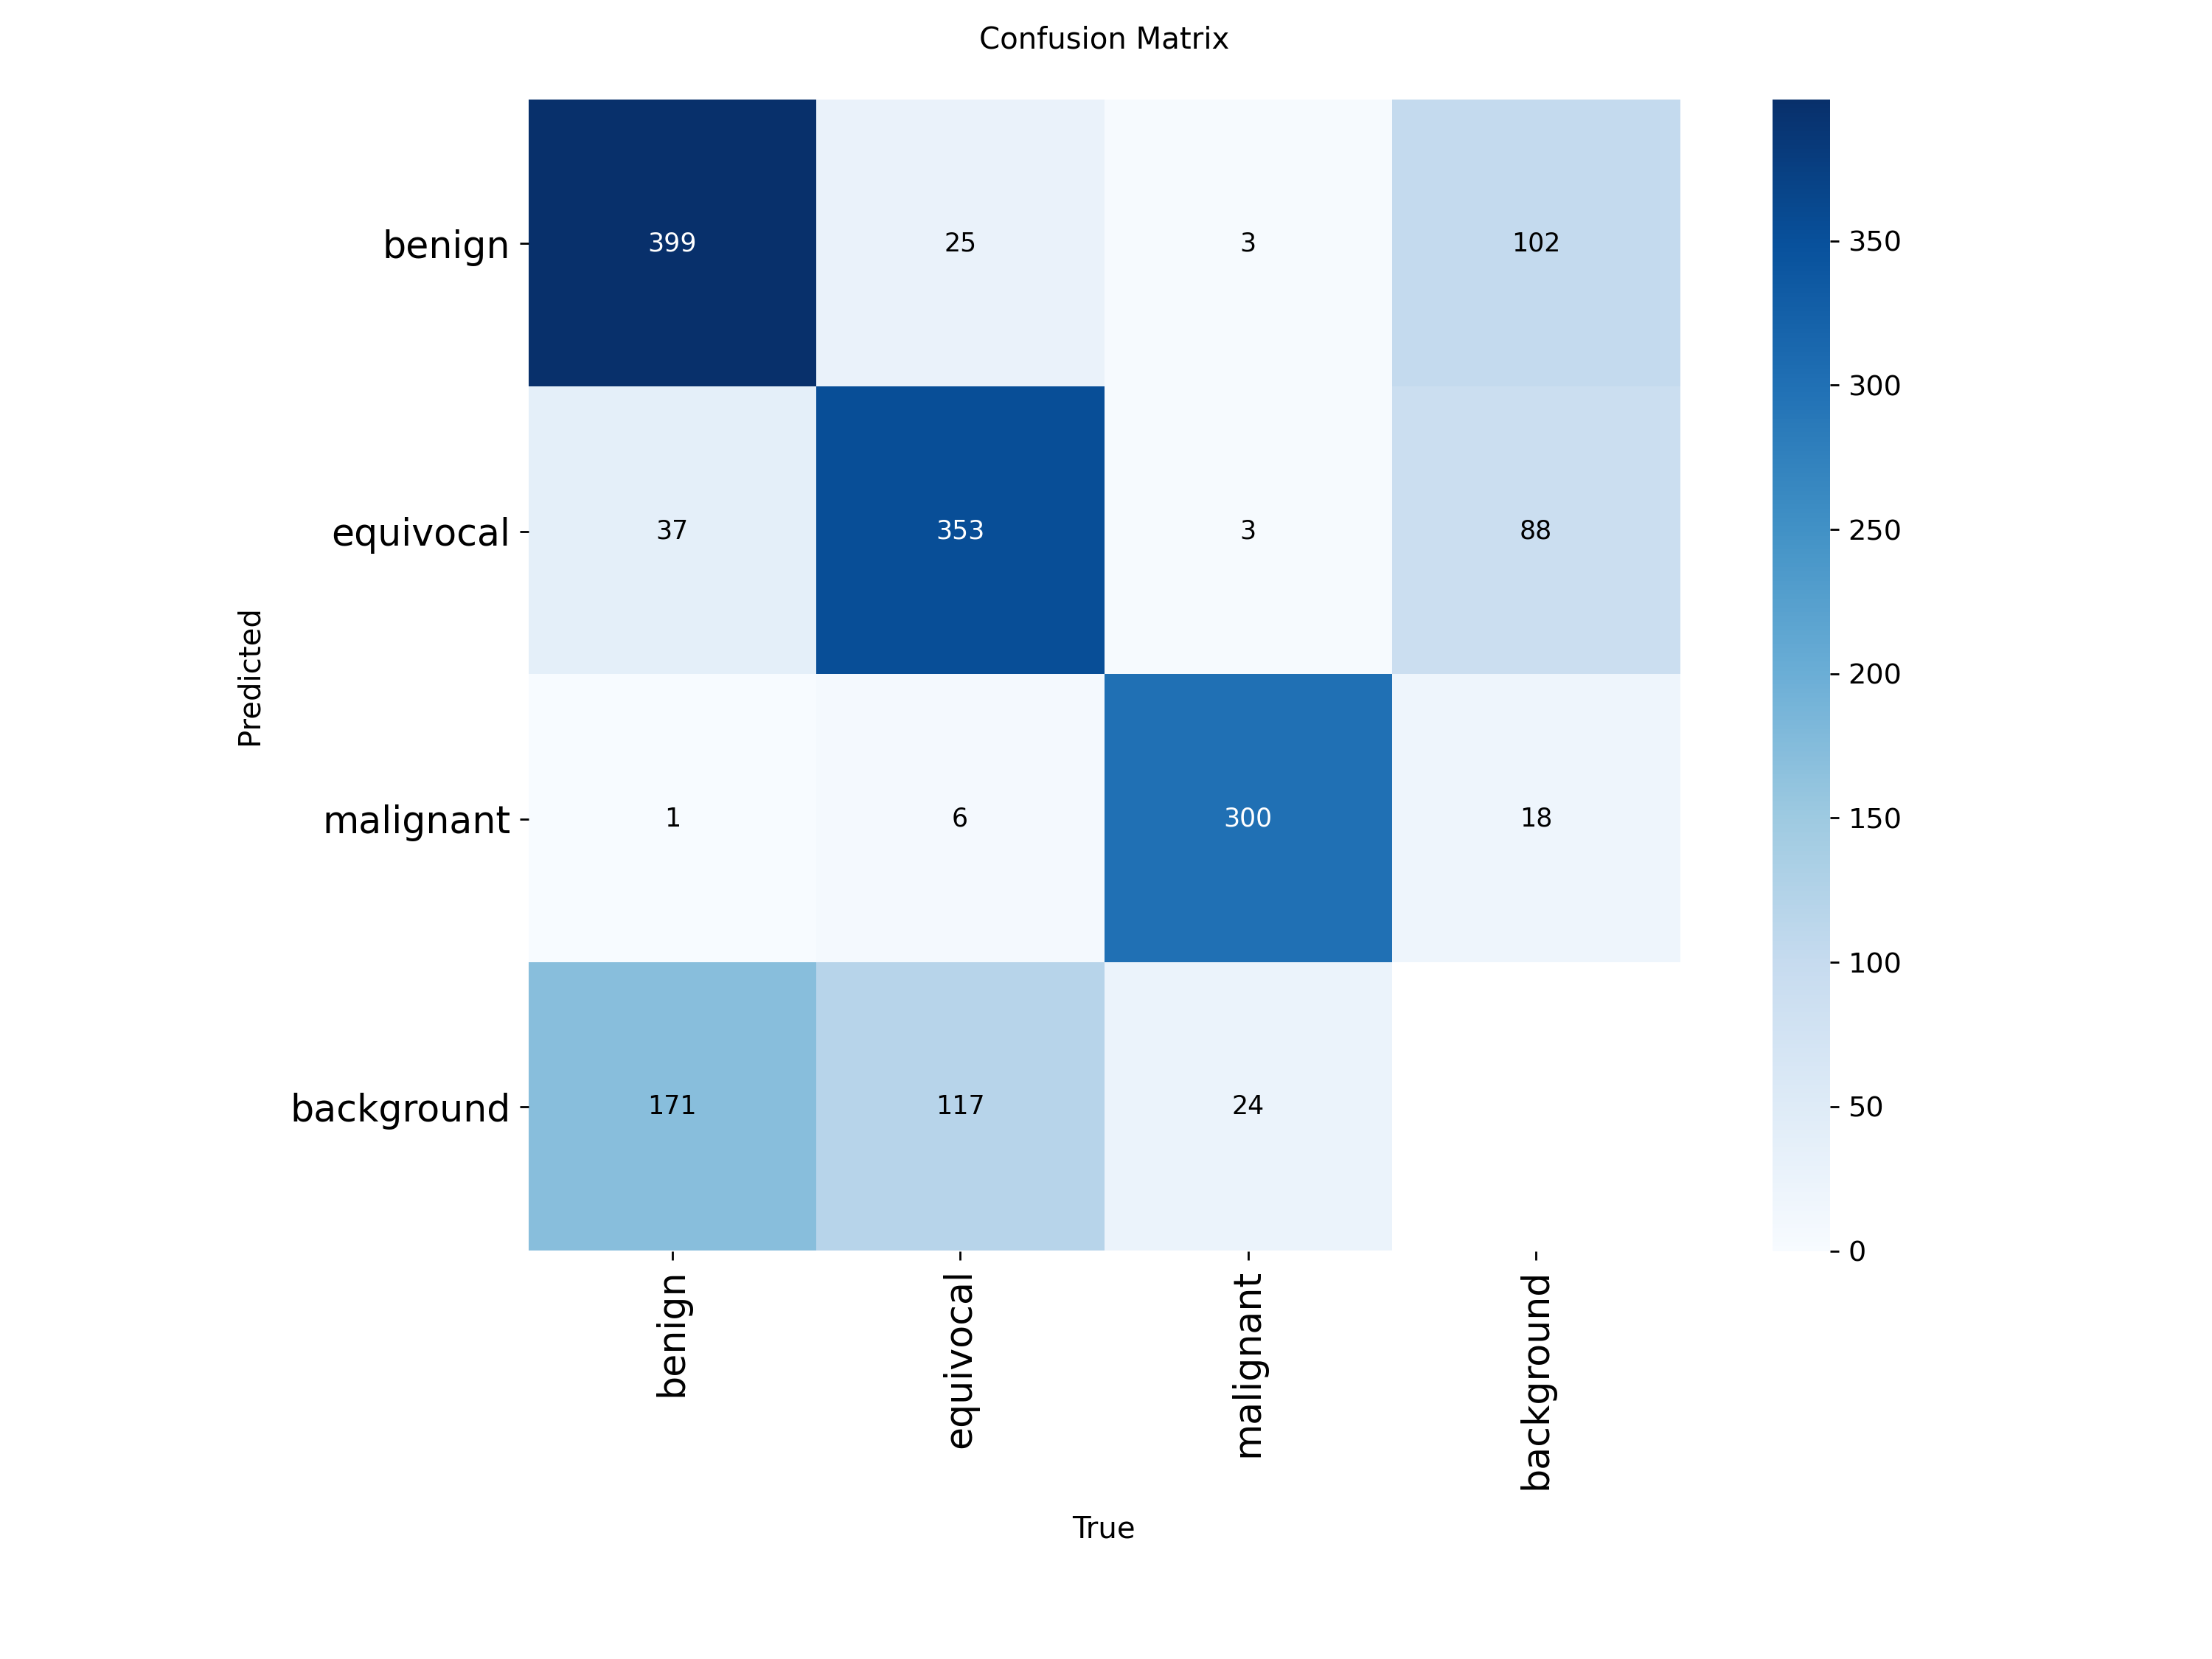


Normalized Confusion Matrix


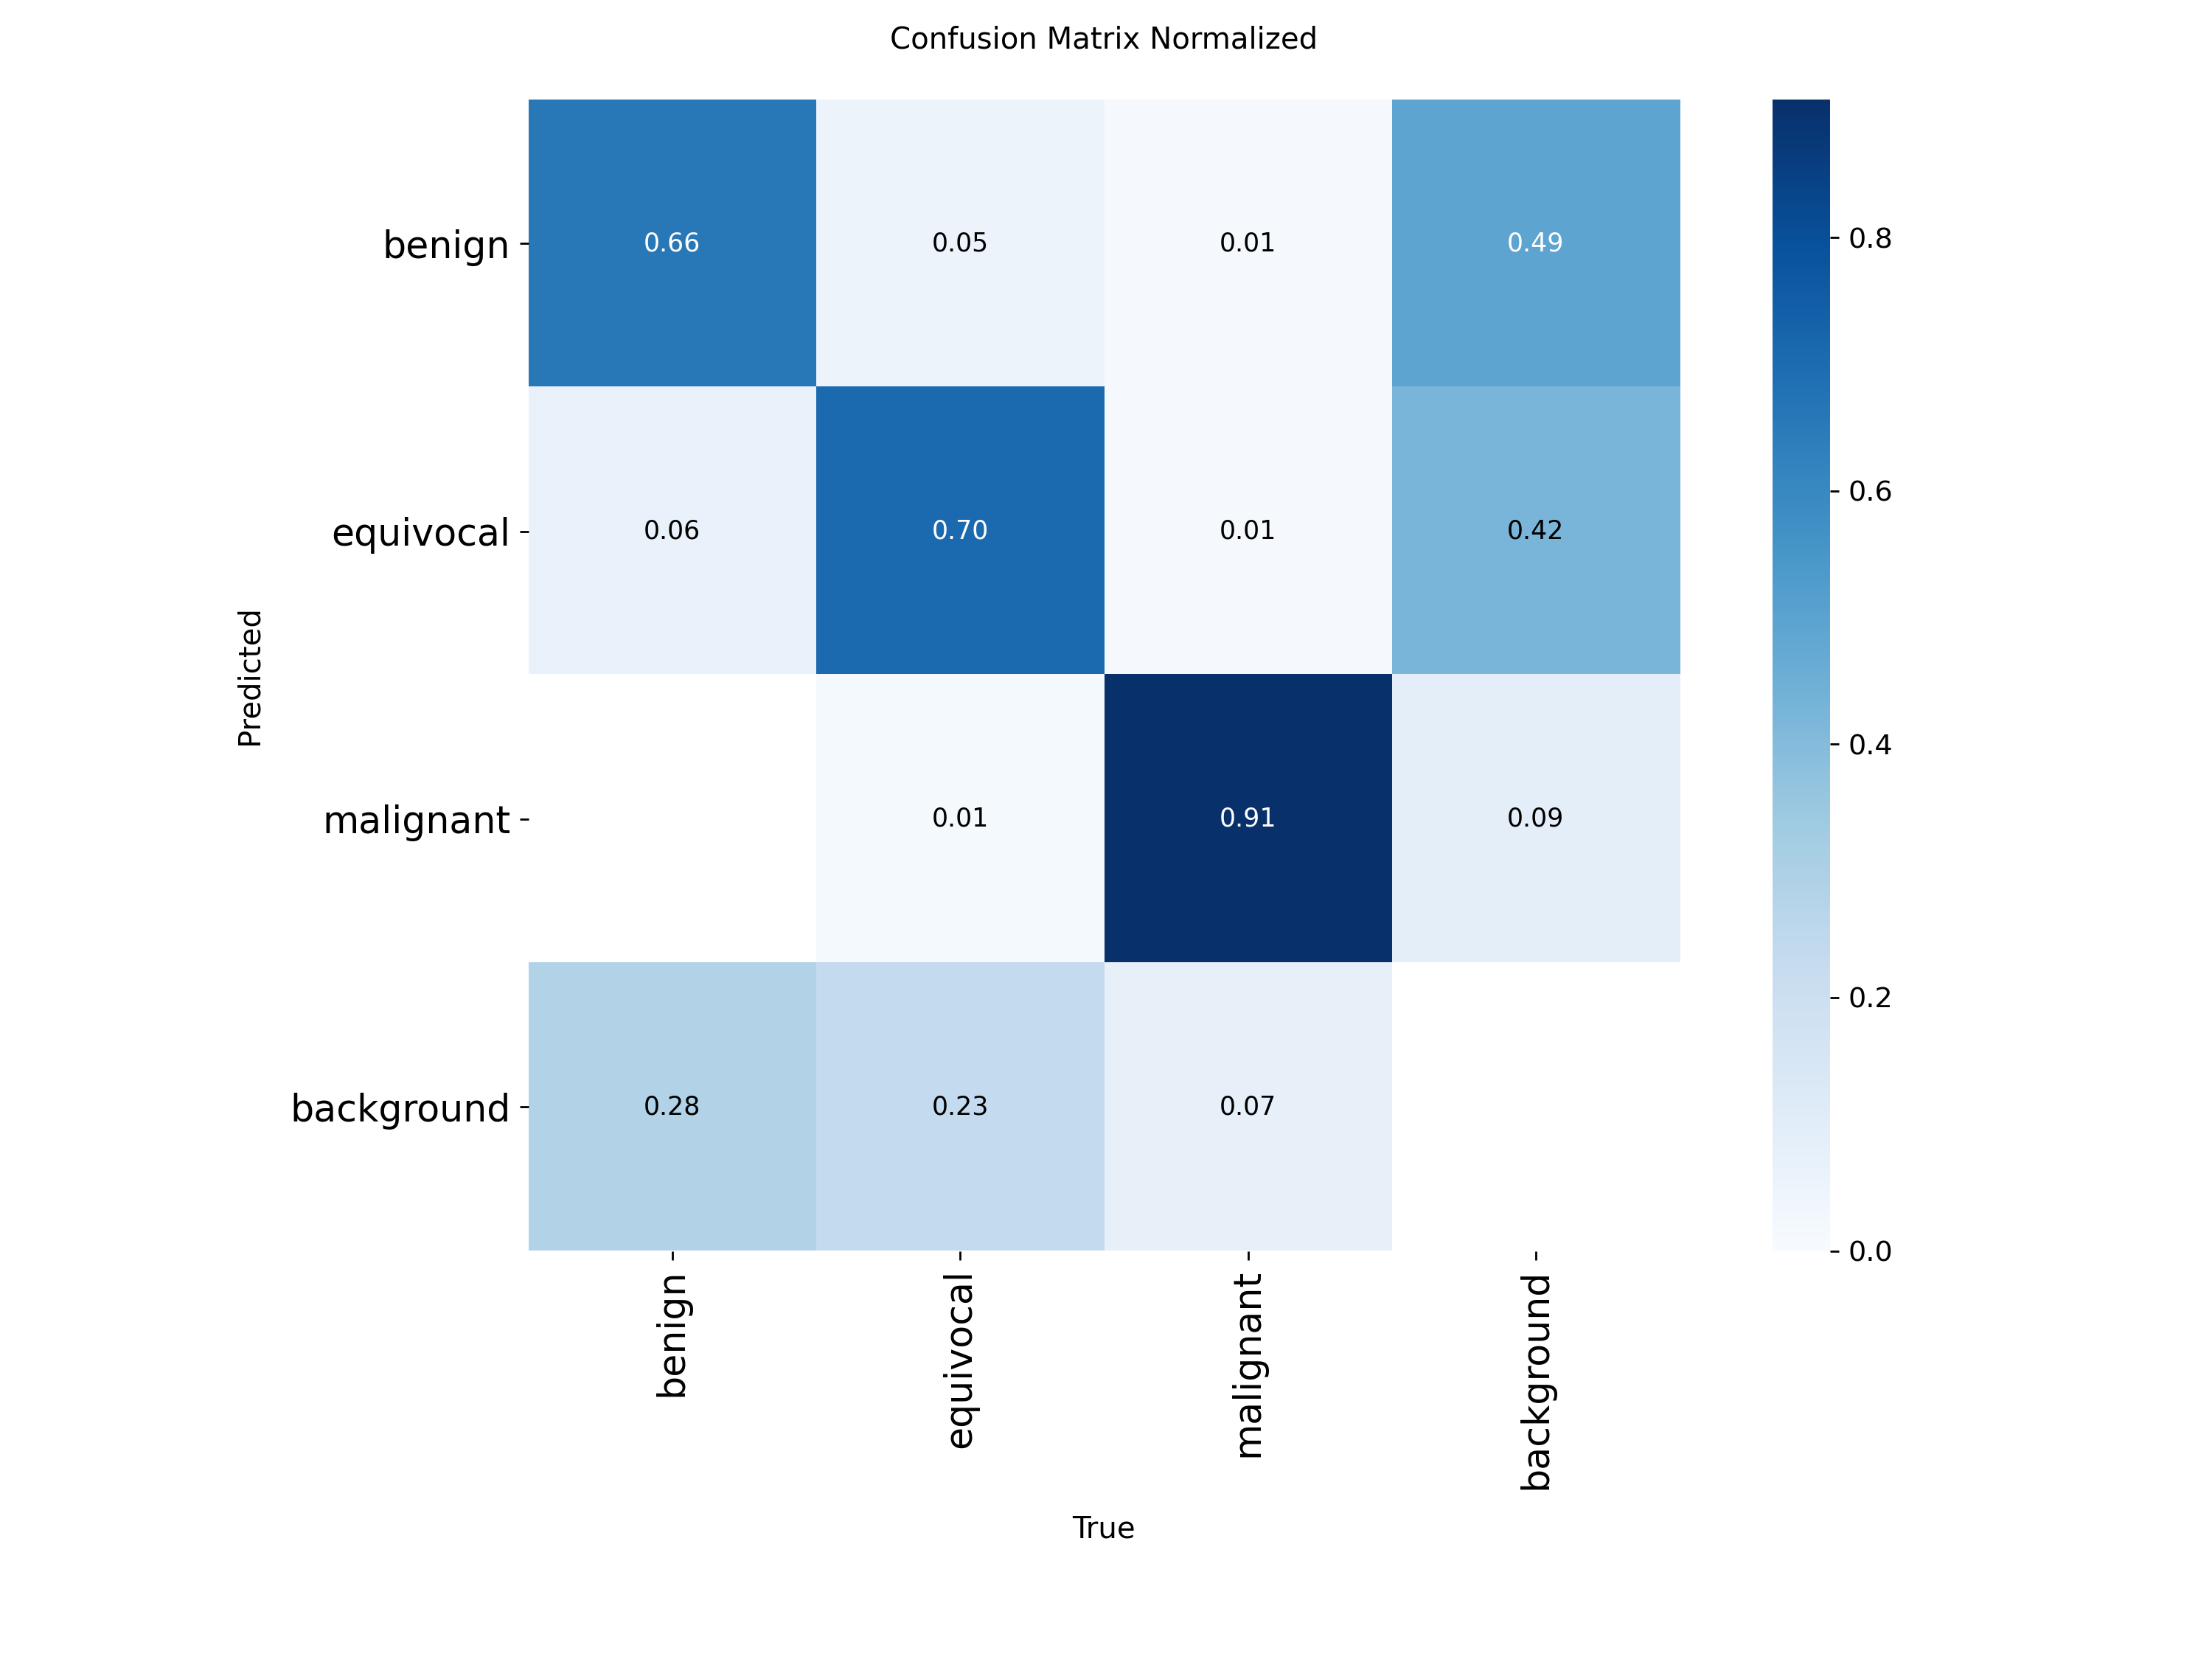


Precision-Recall Curve


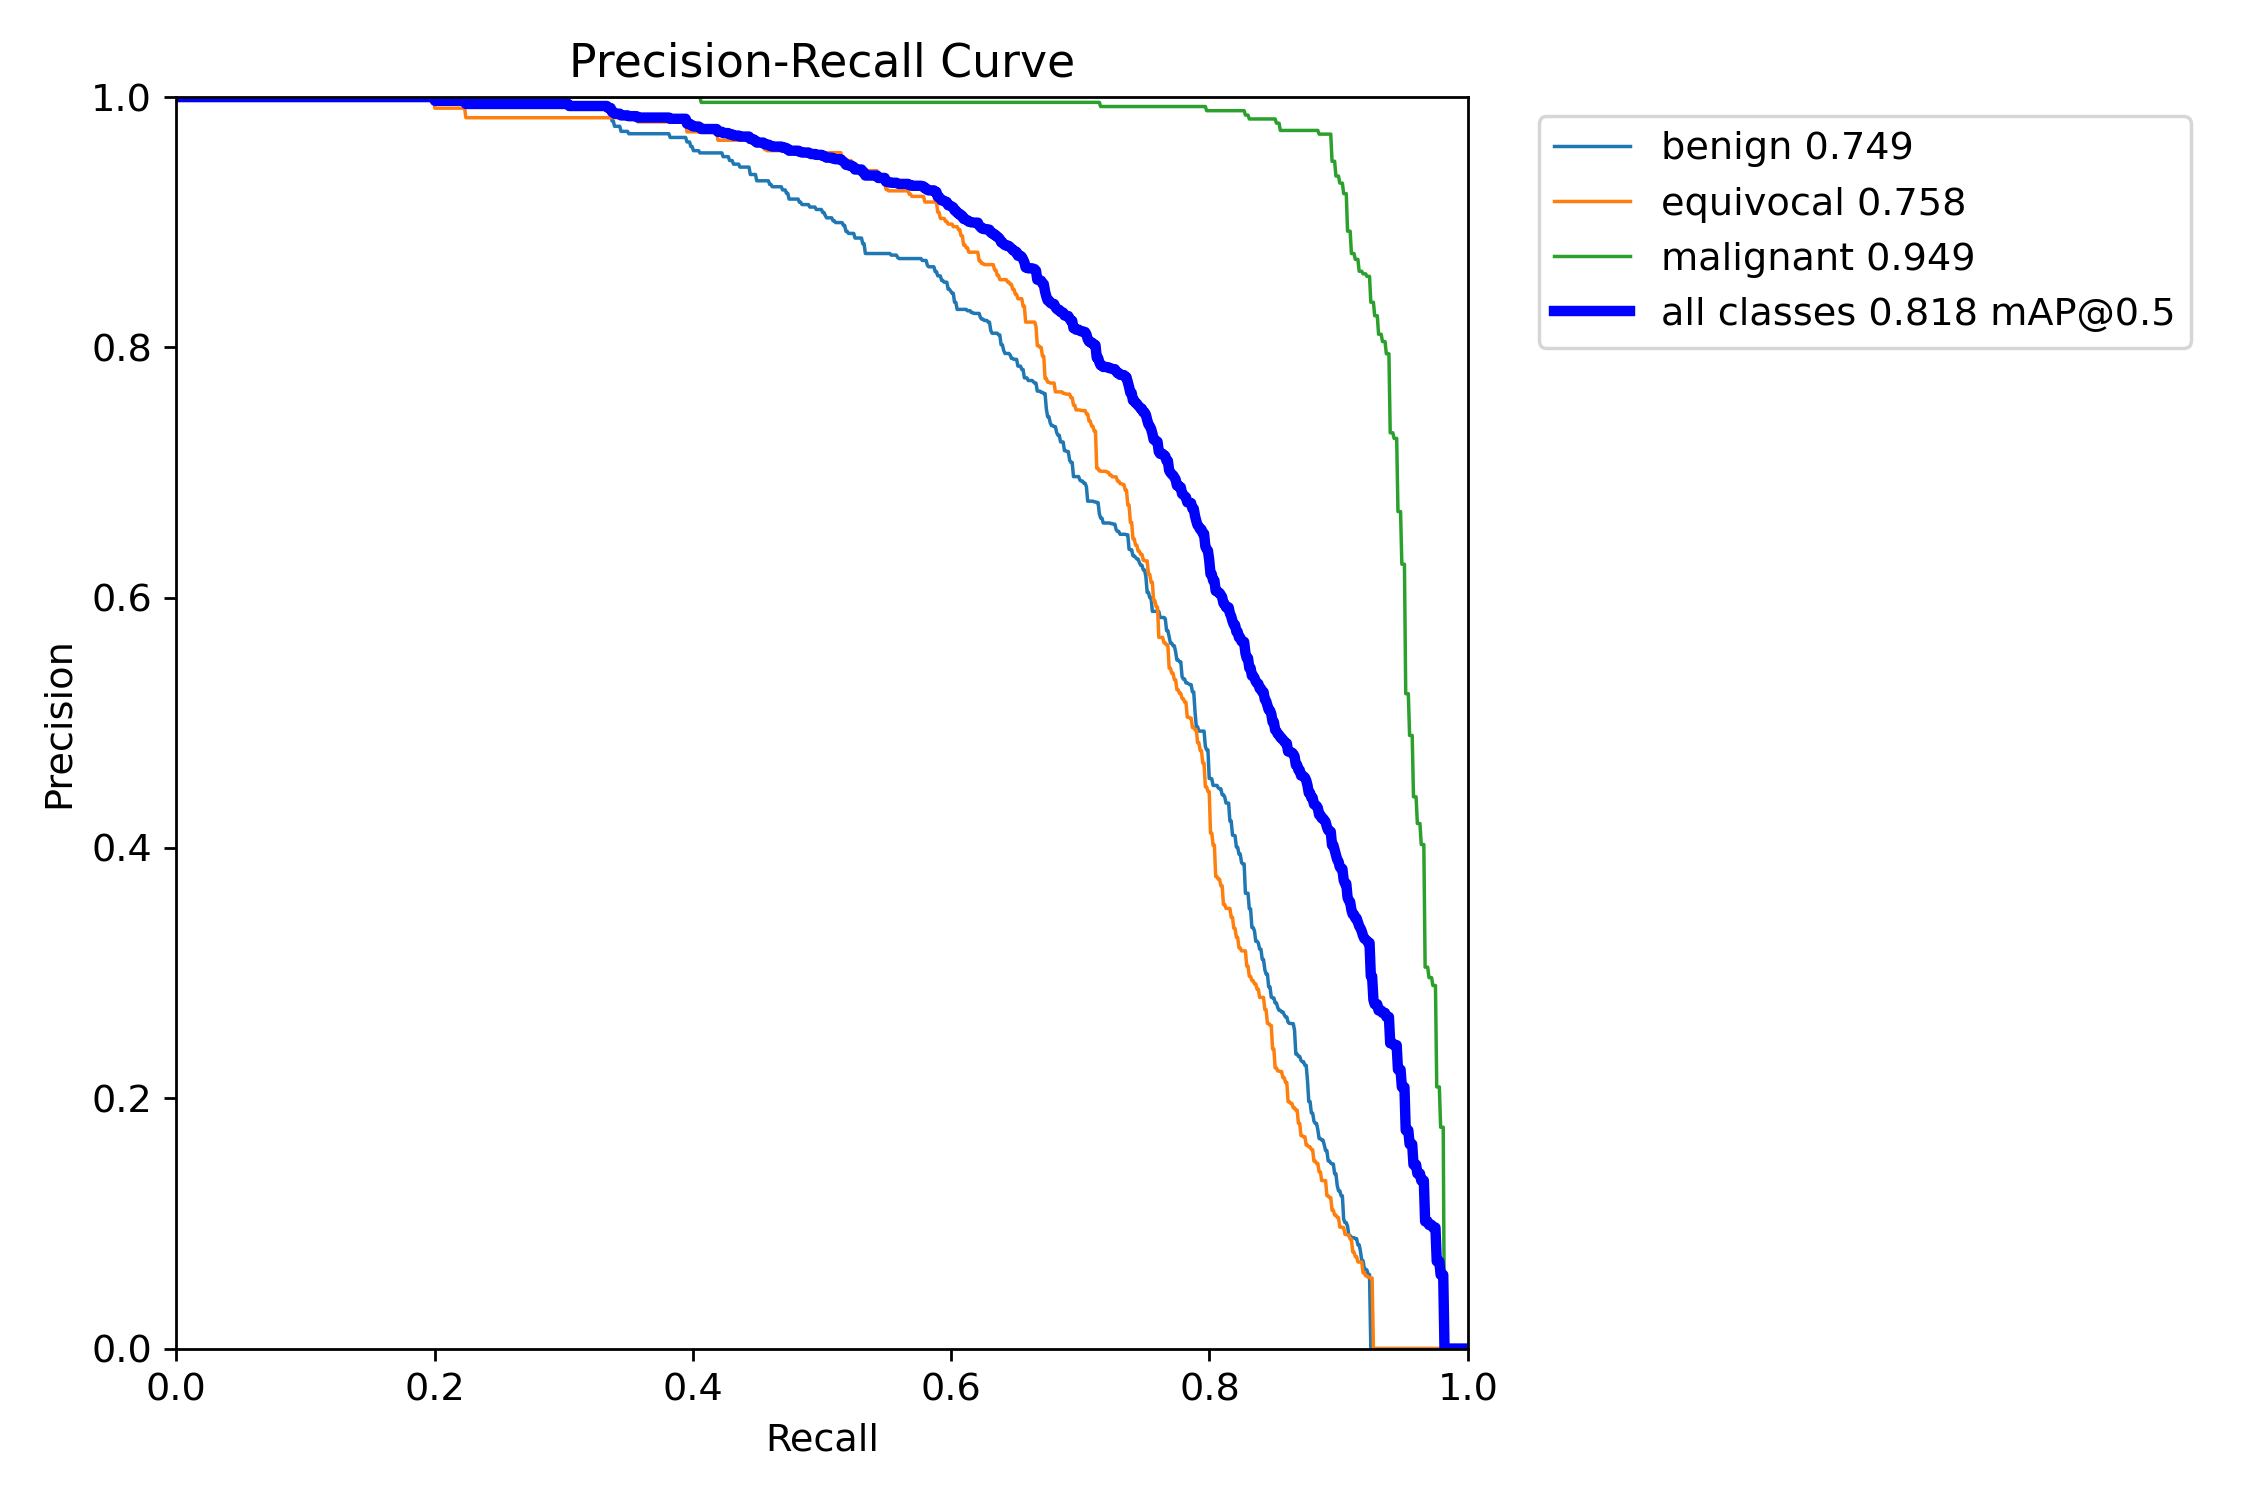


F1-Confidence Curve


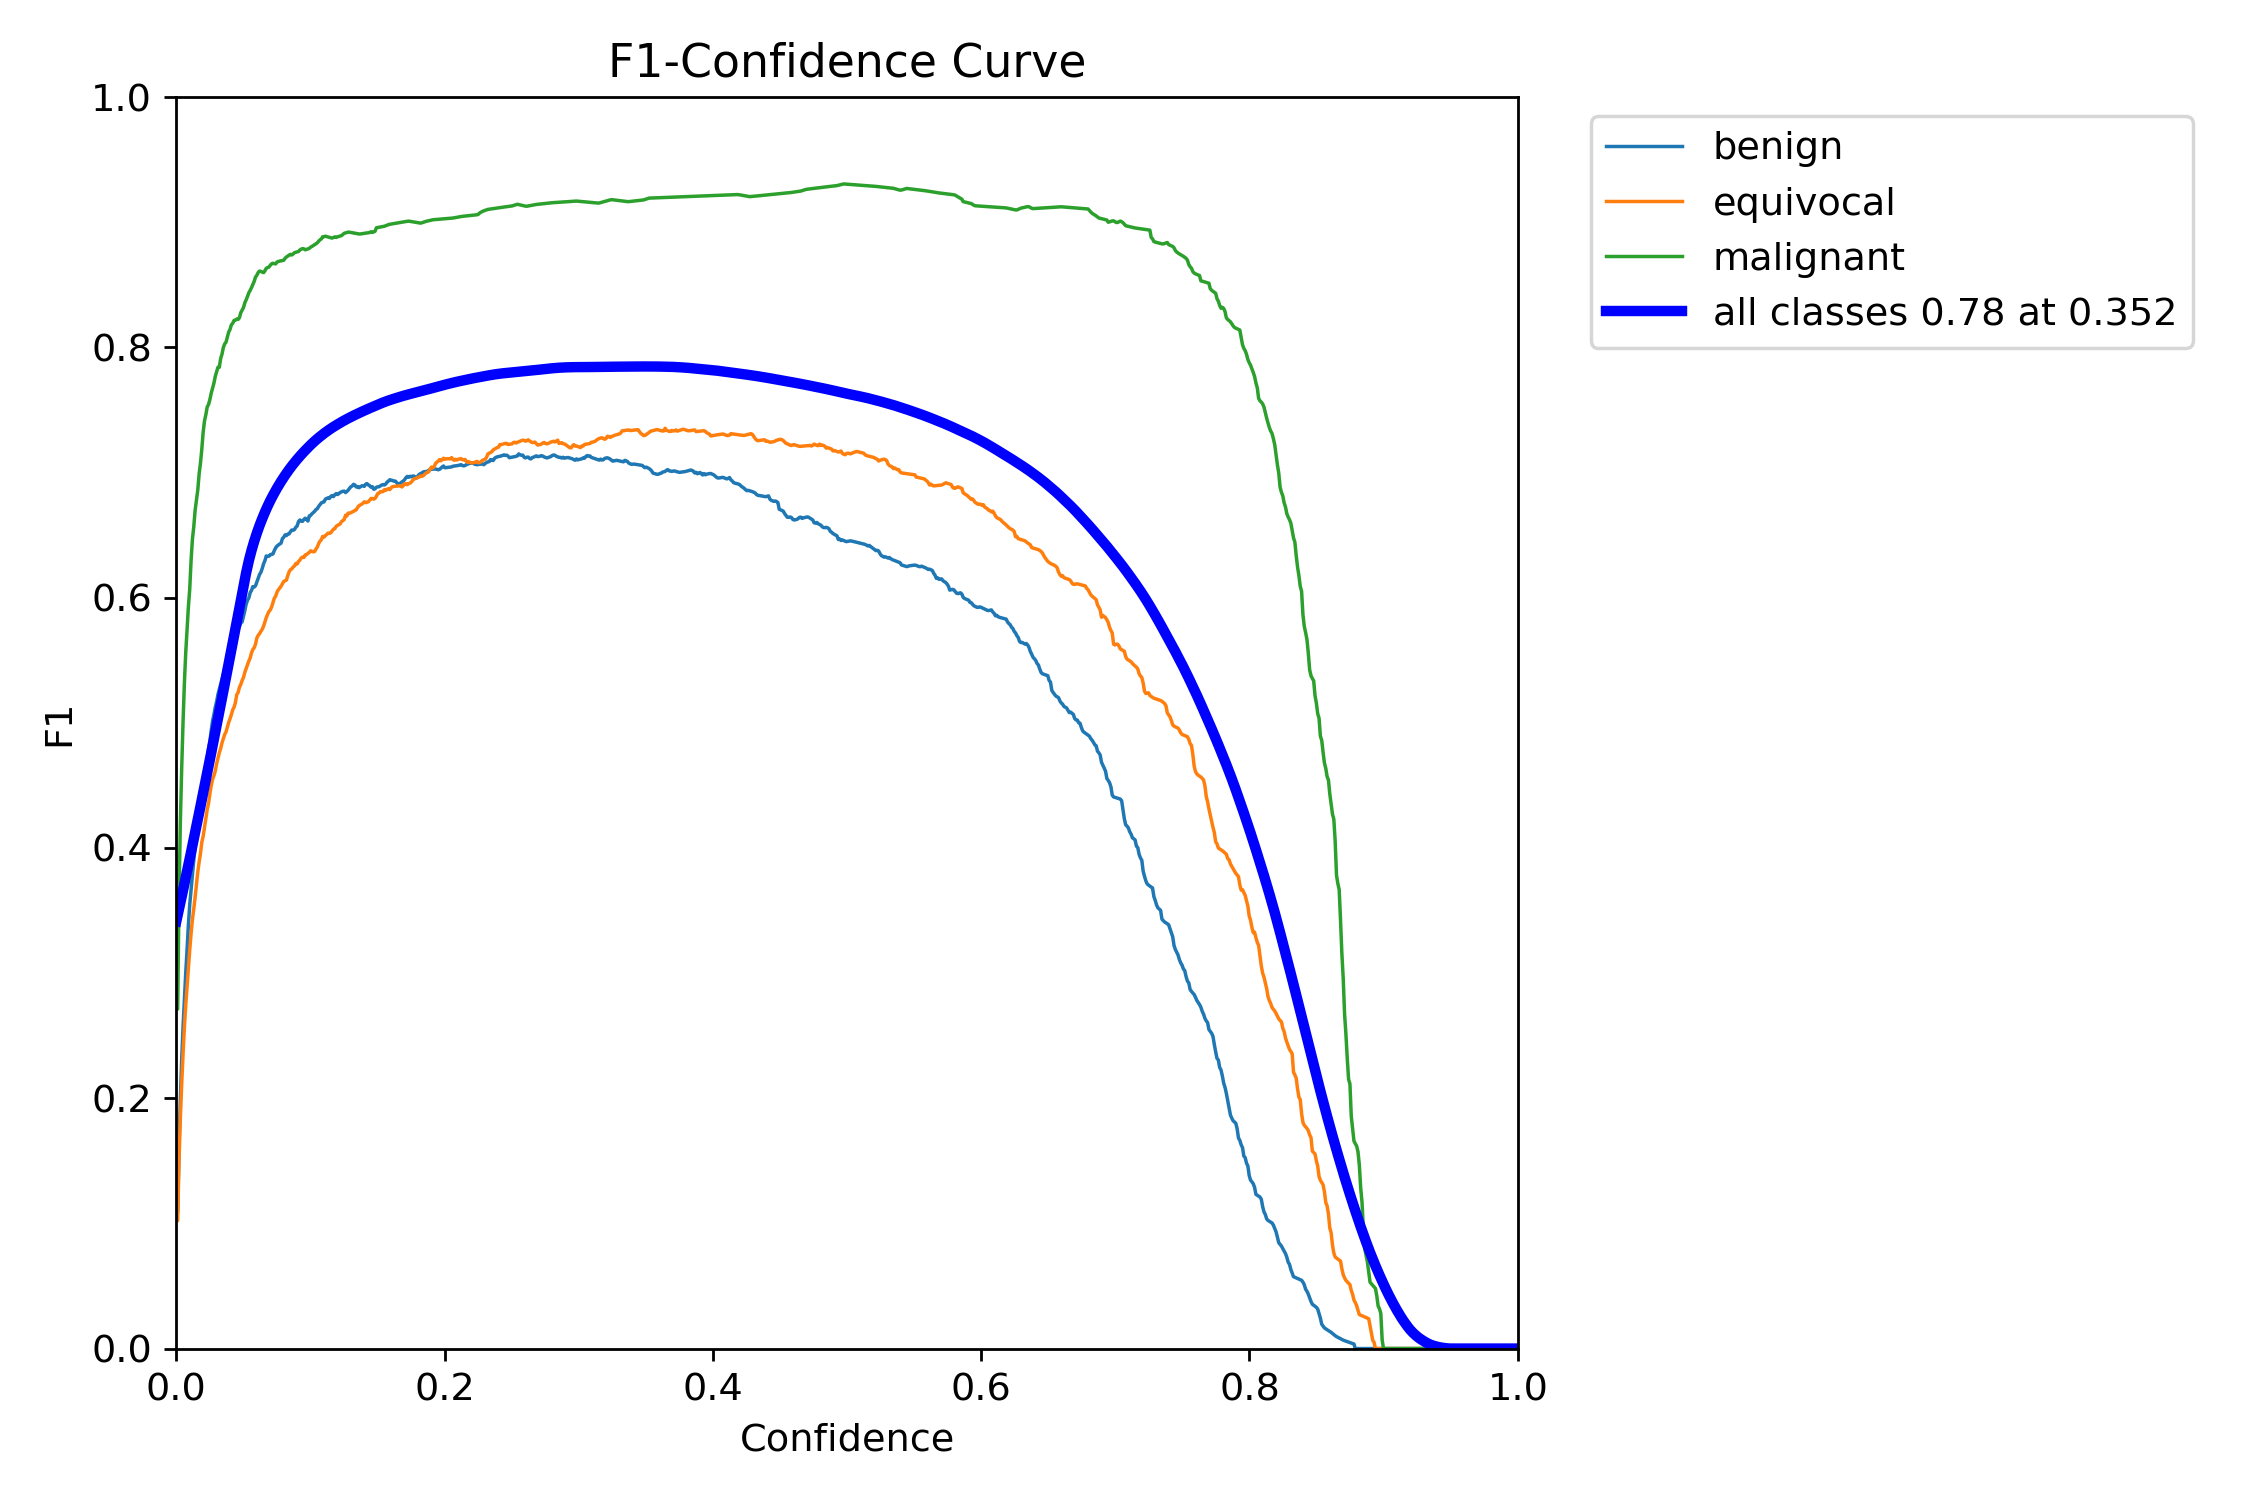


Precision-Confidence Curve


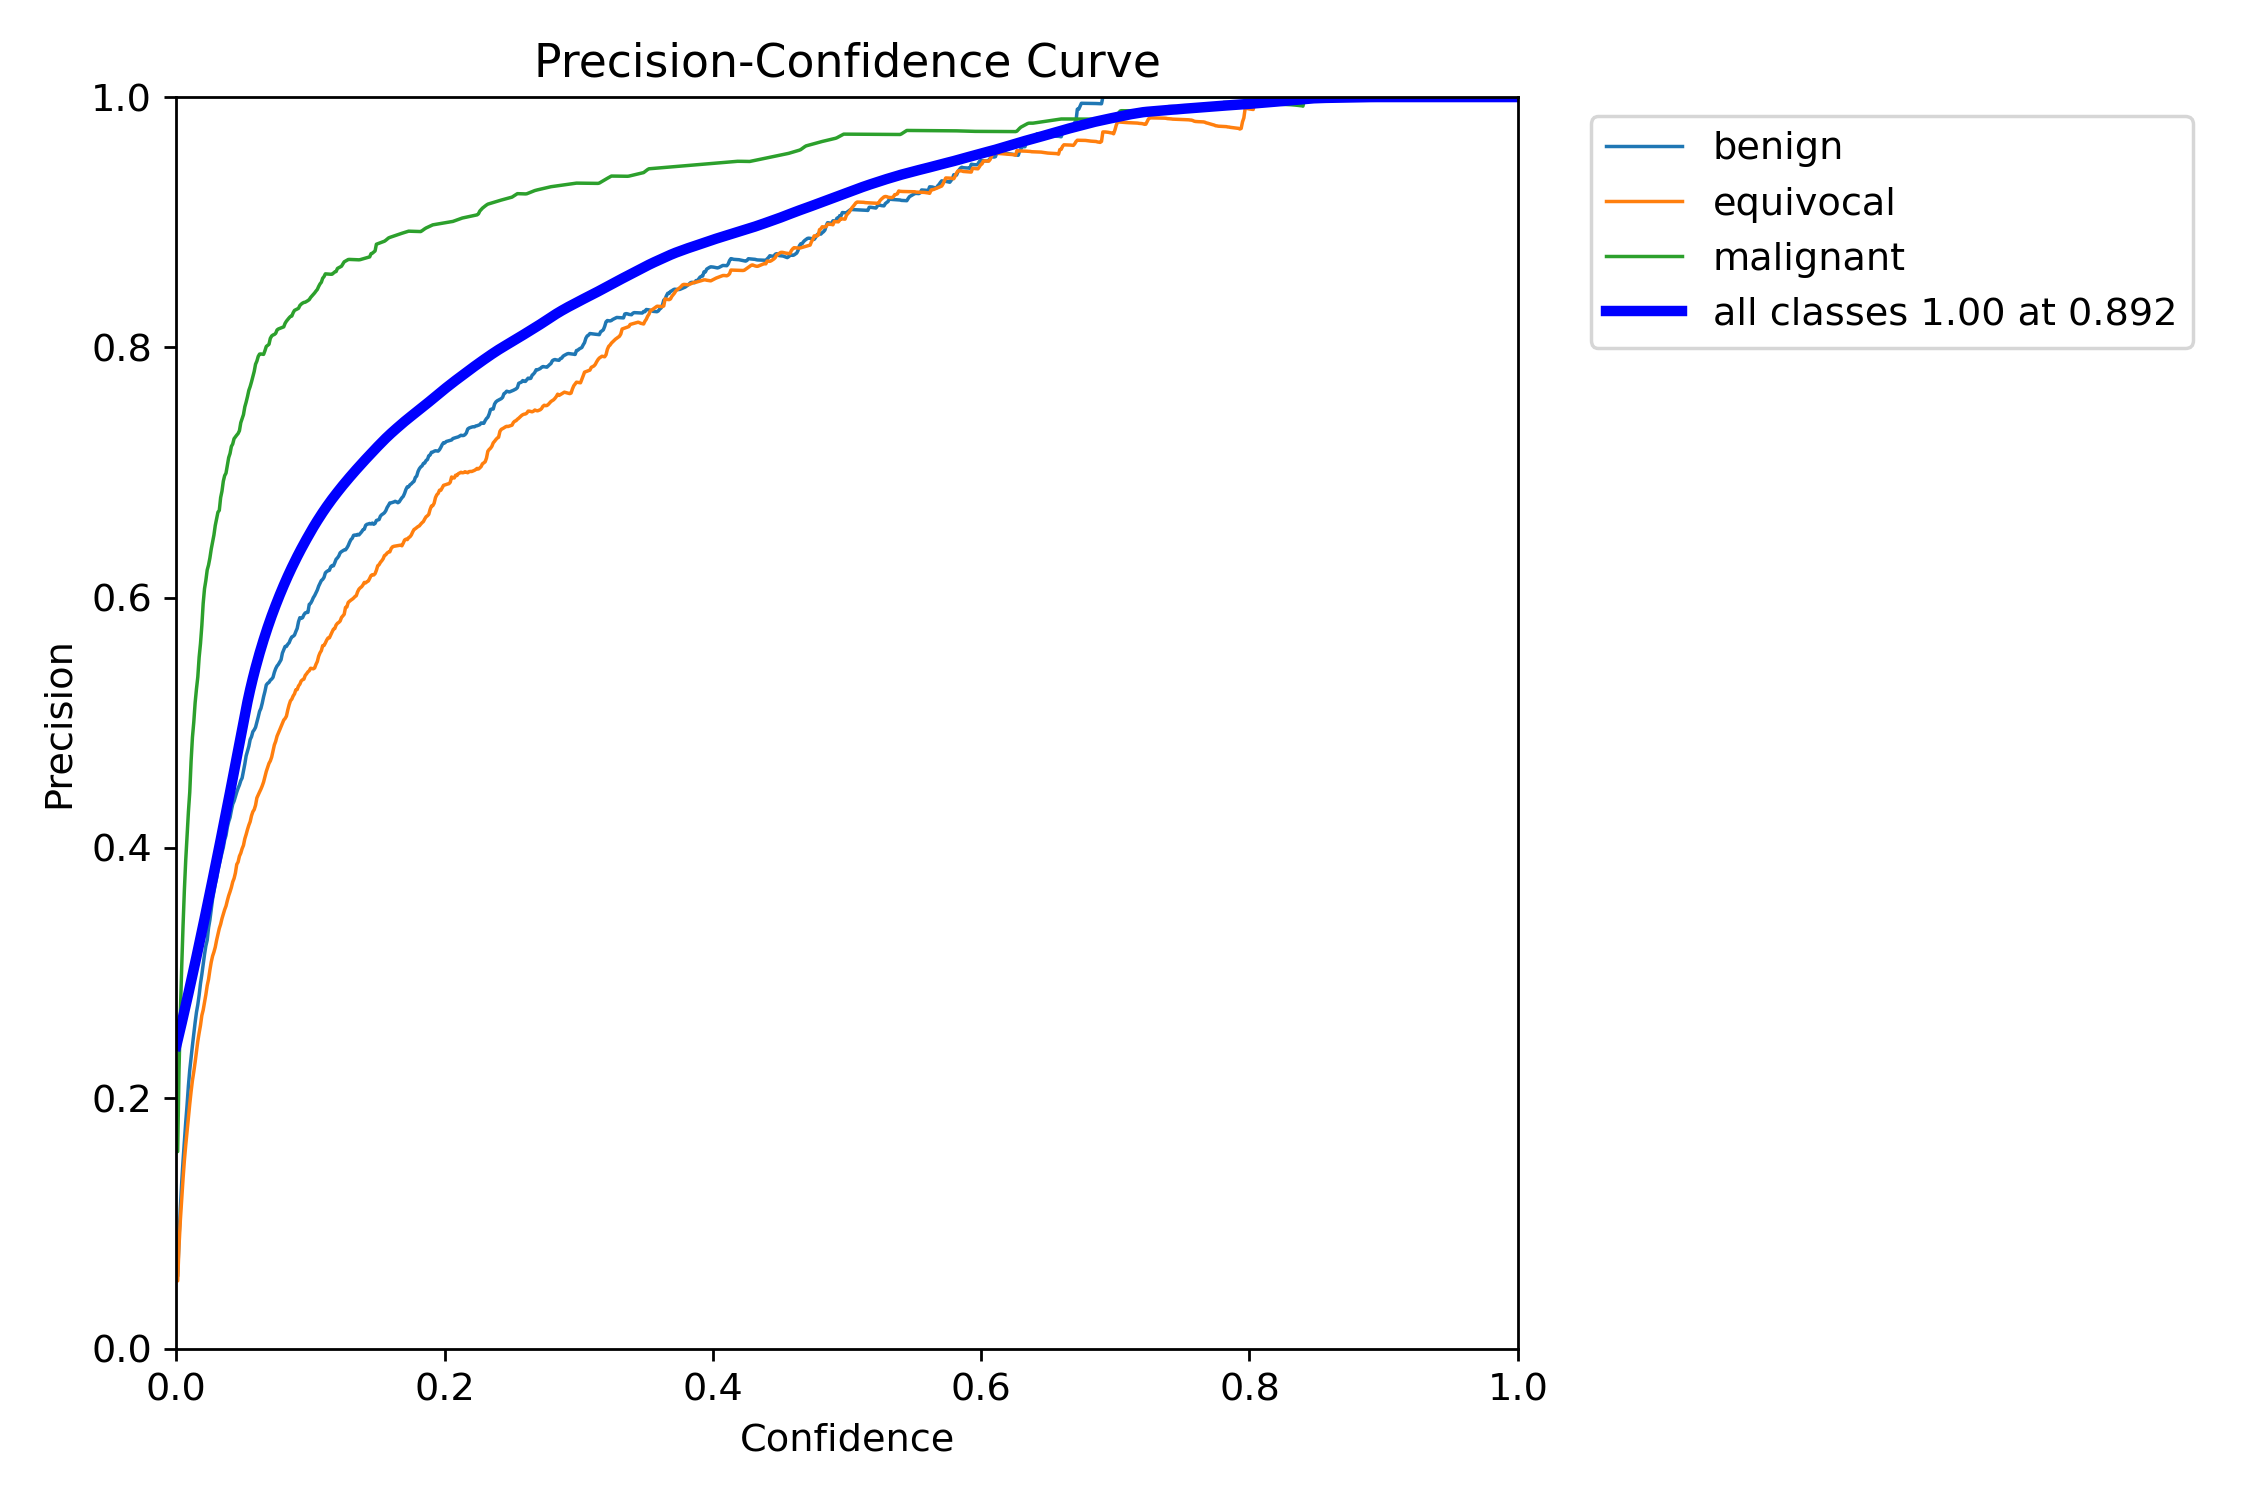


Recall-Confidence Curve


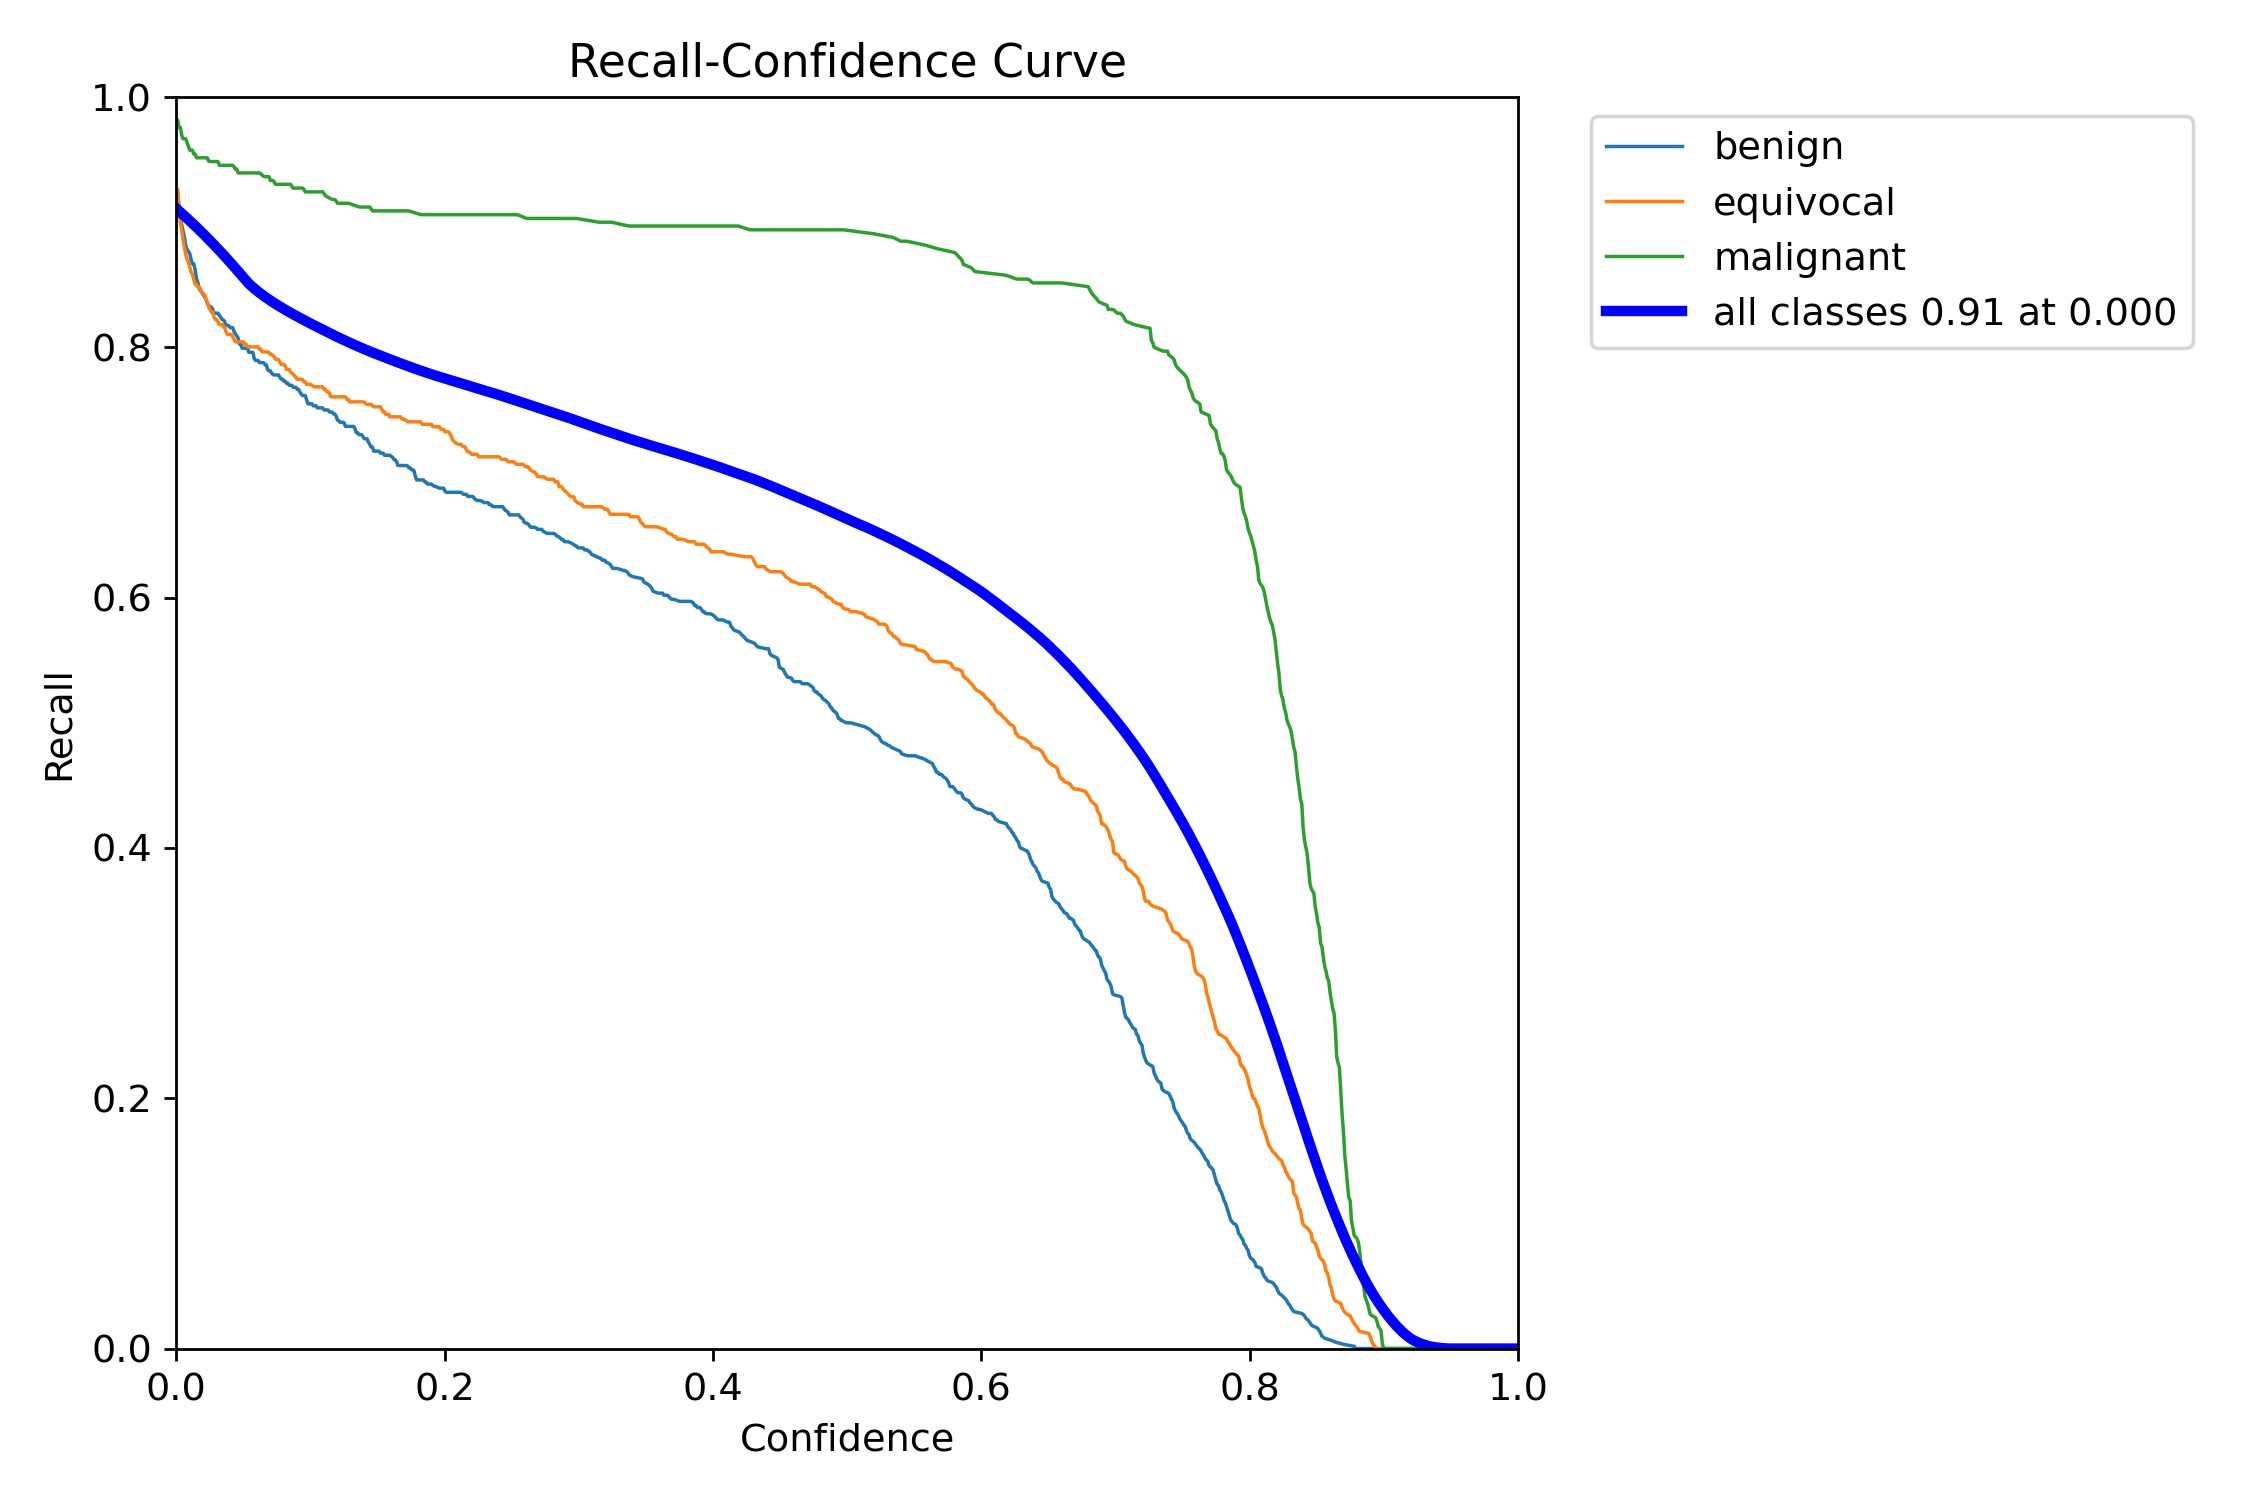

In [14]:
# ============================================================
# 10. DISPLAY TEST-SET EVALUATION PLOTS
# ============================================================

from IPython.display import Image as IPImage

plot_files = [
    ("Confusion Matrix", "confusion_matrix.png"),
    ("Normalized Confusion Matrix", "confusion_matrix_normalized.png"),
    ("Precision-Recall Curve", "BoxPR_curve.png"),
    ("F1-Confidence Curve", "BoxF1_curve.png"),
    ("Precision-Confidence Curve", "BoxP_curve.png"),
    ("Recall-Confidence Curve", "BoxR_curve.png"),
]

for title, filename in plot_files:

    path = os.path.join(TEST_RESULTS_DIR, filename)

    print(f"\n{title}")

    if os.path.exists(path):
        display(IPImage(filename=path))
    else:
        print(f"File not found: {path}")

## 11. Qualitative Test Predictions

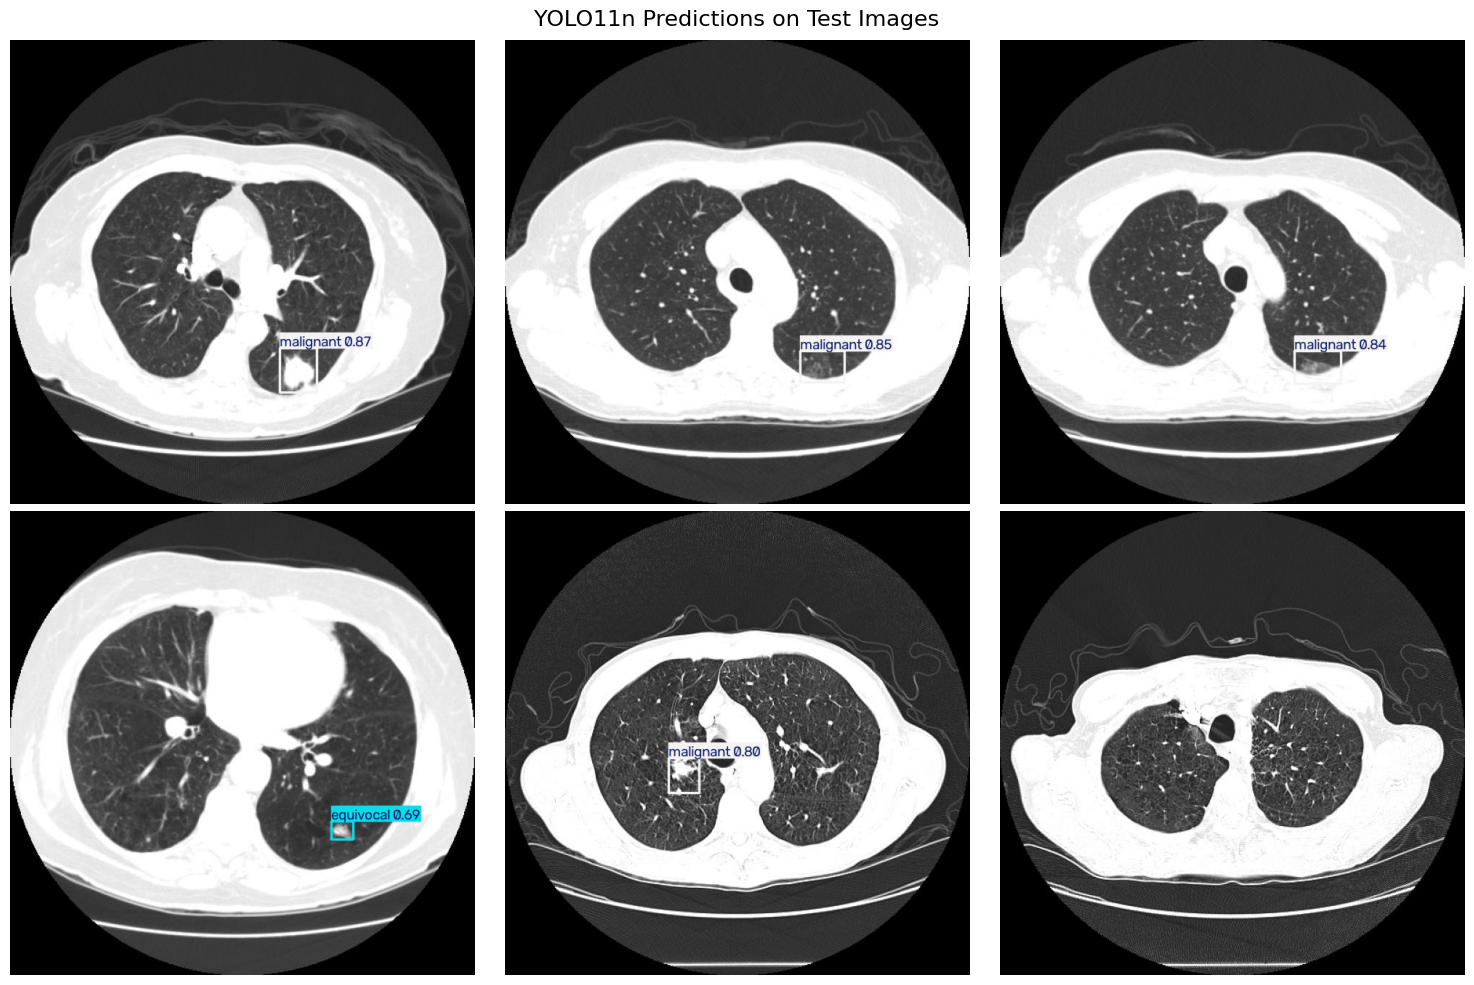

In [15]:
# ============================================================
# 11. QUALITATIVE TEST PREDICTIONS
# ============================================================

# Predict on a small, fixed subset for reproducible visualization.
test_files = sorted([
    os.path.join(TEST_IMAGES, f)
    for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
])

sample_files = test_files[:6]

prediction_results = model.predict(
    source=sample_files,
    conf=0.25,
    save=False,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, result in zip(axes, prediction_results):

    plotted = result.plot()

    ax.imshow(
        cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    )

    ax.axis("off")

plt.suptitle(
    "YOLO11n Predictions on Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 12. Single-Image Inference Demonstration

This section demonstrates inference on one uploaded CT image. The upload interface uses Google Colab's file uploader; the same trained model is used by the standalone Gradio application in `app/app.py`.


Saving LIDC-IDRI-0001_slice_093.bmp to LIDC-IDRI-0001_slice_093.bmp
Number of detections: 1
Detection 1
Class: malignant
Confidence: 85.42%



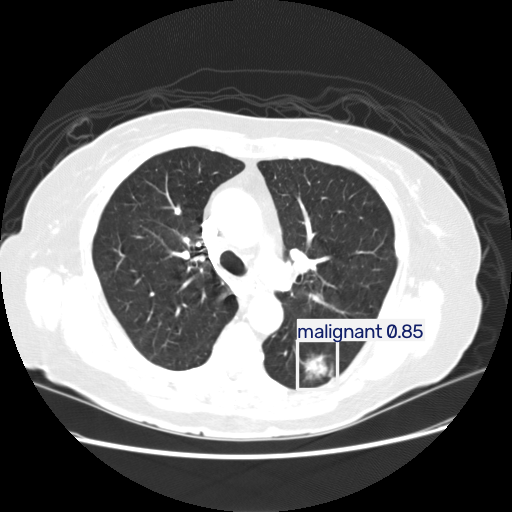

In [16]:
# ============================================================
# 12. SINGLE-IMAGE INFERENCE
# ============================================================

try:
    from google.colab import files
except ImportError:
    raise RuntimeError(
        "This upload demonstration is designed for Google Colab. "
        "Use app/app.py for local/web inference."
    )

uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    inference_results = model.predict(
        source=image_path,
        conf=0.25,
        save=False,
        verbose=False
    )

    result = inference_results[0]

    print("Number of detections:", len(result.boxes))

    for i, box in enumerate(result.boxes):
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(f"Detection {i + 1}")
        print(f"Class: {model.names[class_id]}")
        print(f"Confidence: {confidence:.2%}")
        print()

    display(
        Image.fromarray(
            cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        )
    )


## 13. Web Application

A separate Gradio application is included in **`app/app.py`**.

The application allows a user to:

1. Upload a CT image.
2. Select a confidence threshold.
3. Run YOLO11n inference.
4. View detected bounding boxes.
5. View the predicted class and confidence for each detection.

The application is kept separate from the notebook so that the notebook remains focused on the machine-learning workflow.

> **Research prototype:** The web application is intended for research, educational, and demonstration purposes only. It is not a medical diagnostic tool.


## 14. Conclusion

The project implements a complete object-detection workflow using YOLO11n on the prepared LIDC-IDRI CT Lung Detection dataset.

The workflow includes:

- dataset verification and analysis;
- YOLO-format annotation inspection;
- YOLO11n model training configuration;
- final test-set evaluation;
- confusion matrix and confidence/PR curves;
- qualitative prediction visualization;
- single-image inference;
- a separate Gradio demonstration application.

The final model achieved approximately **86.6% precision, 72.1% recall, 81.9% mAP@50, and 51.6% mAP@50–95** on the test split used in this project.

The prepared dataset contains patient overlap between splits because the provided dataset is organized at the image level. This is documented as a limitation: the reported test performance should therefore be interpreted as performance on the provided image-level test split, rather than as a strictly patient-independent evaluation.

> **Important:** This project is a research/educational prototype and is not intended for medical diagnosis or clinical decision-making.
